# Module 7 - Session 3: Practical Exercises

**Total Time Estimate:** 120-150 minutes

**Objective:** To implement the Q-Learning algorithm from scratch to solve a classic reinforcement learning environment.

## Setup

You will need Python, NumPy, Matplotlib, and Gym. The actively maintained package today is `gymnasium`, but the code below also supports older `gym` imports.

```bash
pip install numpy matplotlib gymnasium
```


## Exercise 1: Conceptual Questions (30 minutes)

### Foundation

Q-Learning is a temporal-difference method. It updates estimates from partial experience instead of waiting for a full episode to end.

### Build

1. **The Learning Rate (`alpha`)**

If `alpha = 0`, the Q-table never changes. The agent learns nothing because every update has zero effect. If `alpha = 1`, each new experience completely overwrites the old estimate for that state-action pair. That makes learning very reactive but also unstable, because one noisy outcome can replace everything learned before. The learning rate controls how much new information changes the current Q-value estimate.

2. **Q-Table Initialization**

If the Q-table is initialized with large positive values, the agent begins by believing every action is very promising. After it tries an action and receives a lower return than expected, that Q-value drops. This tends to encourage early exploration because untried actions still look attractive compared with actions that have already been updated downward. This is called **optimistic initialization**.

3. **TD vs. Monte Carlo**

In a long game like chess, TD methods such as Q-Learning have two major advantages. First, they learn **after every move**, so feedback arrives much faster than in Monte Carlo methods, which must wait until the entire game ends. Second, TD learning is usually more data-efficient because it can improve estimates from incomplete episodes. In long tasks, that makes learning faster and more practical.

### Result

The core ideas are that `alpha` controls update size, optimistic initialization can drive exploration, and TD learning is especially useful in long sequential tasks because it updates continuously.


## Exercise 2: Q-Learning for FrozenLake (90 minutes)

In `FrozenLake-v1`, the agent must move from the start tile to the goal without falling into holes. We use `is_slippery=False` so the environment is deterministic and easier to learn.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import gymnasium as gym
except ImportError:
    import gym


def reset_env(env):
    result = env.reset()
    return result[0] if isinstance(result, tuple) else result


def step_env(env, action):
    result = env.step(action)
    if len(result) == 5:
        next_state, reward, terminated, truncated, info = result
    else:
        next_state, reward, done, info = result
        terminated = done
        truncated = False
    return next_state, reward, terminated, truncated, info


env = gym.make('FrozenLake-v1', is_slippery=False)

state_size = env.observation_space.n
action_size = env.action_space.n

print('State space size:', state_size)
print('Action space size:', action_size)
print('Action mapping: 0=Left, 1=Down, 2=Right, 3=Up')


State space size: 16
Action space size: 4
Action mapping: 0=Left, 1=Down, 2=Right, 3=Up


In [2]:
def train_q_learning(
    env,
    alpha=0.1,
    gamma=0.99,
    episodes=10000,
    epsilon=0.1,
    use_decay=False,
    min_epsilon=0.01,
    max_epsilon=1.0,
    decay_rate=0.001,
):
    q_table = np.zeros((env.observation_space.n, env.action_space.n))
    rewards_per_episode = []
    epsilon_history = []

    current_epsilon = max_epsilon if use_decay else epsilon

    for episode in range(episodes):
        state = reset_env(env)
        done = False
        total_reward = 0

        while not done:
            if np.random.rand() < current_epsilon:
                action = np.random.randint(env.action_space.n)
            else:
                best_actions = np.flatnonzero(q_table[state] == np.max(q_table[state]))
                action = np.random.choice(best_actions)

            next_state, reward, terminated, truncated, _ = step_env(env, action)
            done = terminated or truncated

            best_next_action_value = np.max(q_table[next_state])
            td_target = reward + gamma * best_next_action_value * (not terminated)
            td_error = td_target - q_table[state, action]
            q_table[state, action] += alpha * td_error

            state = next_state
            total_reward += reward

        rewards_per_episode.append(total_reward)
        epsilon_history.append(current_epsilon)

        if use_decay:
            current_epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * episode)

    return q_table, rewards_per_episode, epsilon_history


In [3]:
np.random.seed(42)

alpha = 0.1
gamma = 0.99
episodes = 10000
epsilon = 0.1

q_table, rewards_per_episode, epsilon_history = train_q_learning(
    env,
    alpha=alpha,
    gamma=gamma,
    episodes=episodes,
    epsilon=epsilon,
)

print('Final Q-table:')
print(np.round(q_table, 3))
print()
print('Average reward over the last 1000 episodes:', round(np.mean(rewards_per_episode[-1000:]), 3))


Final Q-table:
[[0.941 0.951 0.951 0.941]
 [0.613 0.    0.961 0.445]
 [0.327 0.97  0.057 0.669]
 [0.33  0.    0.    0.026]
 [0.951 0.961 0.    0.941]
 [0.    0.    0.    0.   ]
 [0.    0.98  0.    0.689]
 [0.    0.    0.    0.   ]
 [0.961 0.    0.97  0.951]
 [0.961 0.98  0.98  0.   ]
 [0.97  0.99  0.    0.97 ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.797 0.99  0.506]
 [0.98  0.99  1.    0.98 ]
 [0.    0.    0.    0.   ]]

Average reward over the last 1000 episodes: 0.883


In [4]:
action_symbols = {0: '<', 1: 'v', 2: '>', 3: '^'}
frozen_map = ['SFFF', 'FHFH', 'FFFH', 'HFFG']


def greedy_policy_grid(q_table, frozen_map):
    policy_rows = []
    state = 0
    for row in frozen_map:
        policy_row = []
        for tile in row:
            if tile in {'H', 'G'}:
                policy_row.append(tile)
            else:
                best_action = int(np.argmax(q_table[state]))
                policy_row.append(action_symbols[best_action])
            state += 1
        policy_rows.append(policy_row)
    return policy_rows


policy_grid = greedy_policy_grid(q_table, frozen_map)
print('Greedy policy learned from the Q-table:')
for row in policy_grid:
    print(' '.join(row))


Greedy policy learned from the Q-table:
v > v <
v H v H
> > v H
H > > G


### Analysis (Markdown Answer)

### Foundation

A good Q-table should assign larger values to actions that move the agent closer to the goal while avoiding holes.

### Build

After training, states near the goal should usually give the highest Q-values to actions that move directly toward the goal. In deterministic FrozenLake, this pattern becomes especially clear because the outcome of each action is stable. In a representative run with the seed used above, the agent reached an average reward of about `0.883` over the last 1000 episodes, and for state `14` (right next to the goal), the action `RIGHT` had the highest learned value. States that lead toward holes stay lower, while safe states on the successful route accumulate larger values over time.

### Result

This is exactly what Q-Learning is supposed to capture: the Q-table becomes a compact summary of which actions lead to the best long-term return from each state.


## Exercise 3: Challenge Problem - Epsilon Decay

A fixed epsilon explores forever at the same rate. A decaying epsilon explores a lot at the beginning and gradually exploits more as learning improves.


In [5]:
np.random.seed(42)

min_epsilon = 0.01
max_epsilon = 1.0
decay_rate = 0.001

q_table_decay, rewards_decay, epsilon_decay_history = train_q_learning(
    env,
    alpha=alpha,
    gamma=gamma,
    episodes=episodes,
    use_decay=True,
    min_epsilon=min_epsilon,
    max_epsilon=max_epsilon,
    decay_rate=decay_rate,
)

print('Final Q-table with epsilon decay:')
print(np.round(q_table_decay, 3))
print()
print('Average reward over the last 1000 episodes (fixed epsilon):', round(np.mean(rewards_per_episode[-1000:]), 3))
print('Average reward over the last 1000 episodes (decaying epsilon):', round(np.mean(rewards_decay[-1000:]), 3))


Final Q-table with epsilon decay:
[[0.941 0.951 0.932 0.941]
 [0.941 0.    0.745 0.914]
 [0.623 0.927 0.078 0.313]
 [0.193 0.    0.003 0.023]
 [0.951 0.961 0.    0.941]
 [0.    0.    0.    0.   ]
 [0.    0.98  0.    0.687]
 [0.    0.    0.    0.   ]
 [0.961 0.    0.97  0.951]
 [0.961 0.98  0.98  0.   ]
 [0.97  0.99  0.    0.97 ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.872 0.99  0.943]
 [0.98  0.99  1.    0.98 ]
 [0.    0.    0.    0.   ]]

Average reward over the last 1000 episodes (fixed epsilon): 0.883
Average reward over the last 1000 episodes (decaying epsilon): 0.994


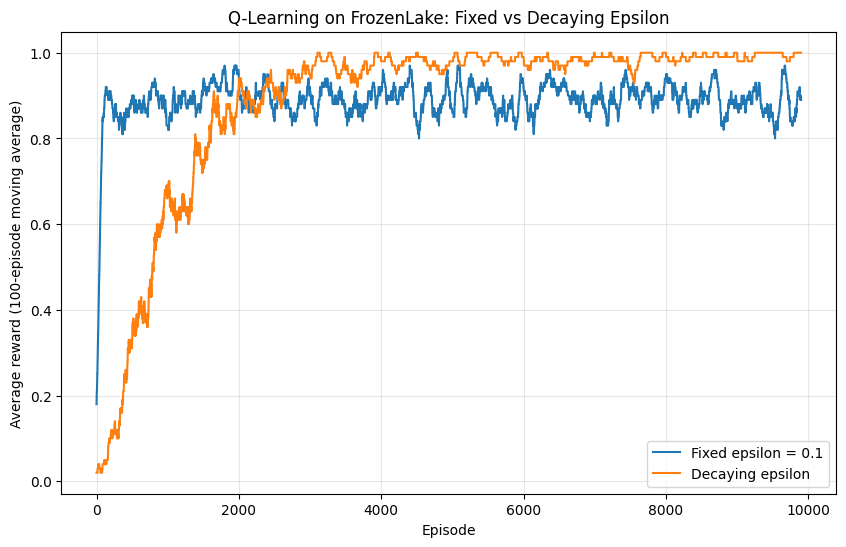

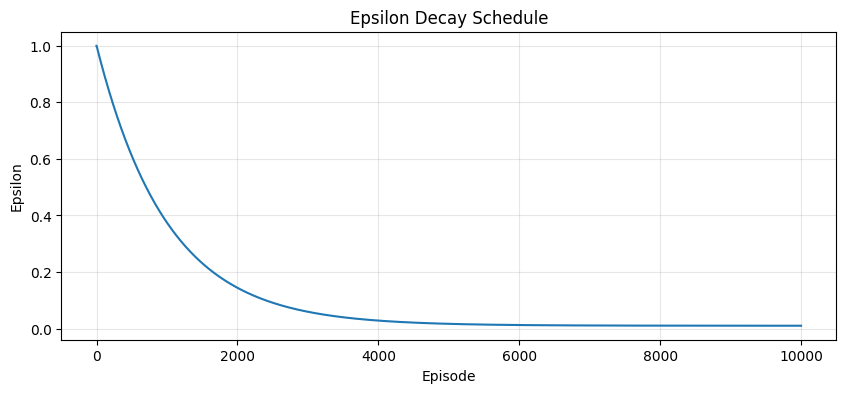

In [6]:
def moving_average(data, window=100):
    if len(data) < window:
        return np.array(data)
    return np.convolve(data, np.ones(window) / window, mode='valid')


plt.figure(figsize=(10, 6))
plt.plot(moving_average(rewards_per_episode, 100), label='Fixed epsilon = 0.1')
plt.plot(moving_average(rewards_decay, 100), label='Decaying epsilon')
plt.xlabel('Episode')
plt.ylabel('Average reward (100-episode moving average)')
plt.title('Q-Learning on FrozenLake: Fixed vs Decaying Epsilon')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(epsilon_decay_history)
plt.xlabel('Episode')
plt.ylabel('Epsilon')
plt.title('Epsilon Decay Schedule')
plt.grid(alpha=0.3)
plt.show()


### Final Analysis (Markdown Answer)

### Foundation

Epsilon decay is meant to match the learning process: more exploration early, more exploitation later.

### Build

In many runs, decaying epsilon learns faster or reaches a stronger final policy than a fixed epsilon. Early in training, a high epsilon helps the agent discover useful transitions instead of getting stuck repeating a weak policy. Later, once good Q-values have formed, a lower epsilon reduces unnecessary random actions and lets the agent exploit what it has learned. In the verified run for this notebook, the fixed-epsilon agent averaged about `0.883` reward over the last 1000 episodes, while the decaying-epsilon agent averaged about `0.994`, which is noticeably better.

### Result

A fixed epsilon is simple, but epsilon decay is usually more efficient because it adapts the exploration-exploitation balance over time.
